In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import numpy as np
import struct
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
class CustomDataset(Dataset):
    # LSTM input은 (batch, sequence_len, input_size) -> channel 필요 X
    def __init__(self, images, labels=None):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32)  # shape: (28, 28)
        if self.labels is not None:
            return img, int(self.labels[idx])
        return img

In [3]:
with open('./datasets/mnist/train-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    images = np.fromfile(f, dtype=np.uint8).reshape(n, rows, cols)
    # LSTM: reshape(n, rows, cols) -> rows가 time step을 나타낸다.

with open('./datasets/mnist/train-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    labels = np.fromfile(f, dtype=np.uint8)

with open('./datasets/mnist/t10k-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    test_images = np.fromfile(f, dtype=np.uint8).reshape(n, rows, cols)

with open('./datasets/mnist/t10k-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    test_labels = np.fromfile(f, dtype=np.uint8)

images      = images.astype(np.float32)      / 255.0
test_images = test_images.astype(np.float32) / 255.0

train_dataset = CustomDataset(images, labels)
test_dataset  = CustomDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)

In [4]:
print(len(train_dataset))
print(len(test_dataset))

60000
10000


**nn.LSTM(input_size, hidden_size, num_layers, batch_first, dropout, bidirectional)**
* **input_size**: 각 time step(rows)의 feature 크기 (MNIST: 28, 이미지 width pixel 수)
* **hidden_size**: 일반적으로 128 시작, 성능 부족 시 *2, overfitting or 학습이 느린 경우 /2
* **num_layers**: 일반적으로 1~2, 깊게 쌓을수록 복잡한 시퀀스 패턴 학습 가능
* **batch_first**: True 고정 (입력 shape을 (batch, sequence, feature) 순서로 받기 위함)
* **dropout**: num_layers > 1일 때만 적용, 일반적으로 0.2~0.5
* **proj_size**: 0보다 크면 hidden state를 proj_size 차원으로 projection하는 LSTMP(Projected LSTM) 구조가 된다. (default: 0 (disabled))

**nn.Linear(in_features, out_features)**
* **in_features**: 첫 번째 Linear는 hidden_size와 동일, 이후는 이전 layer의 out_features와 동일
* **out_features**: hidden_size / 2로 시작해 점진적으로 1/2씩 감소, 마지막 Linear는 class 수

In [5]:
class LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=28,
            hidden_size=128,  # acc가 낮다면 x2, overfitting이거나 학습이 느리면 /2
            num_layers=2,
            batch_first=True,  # 입력 shape: (batch, seq, feature) 순서
            dropout=0.3  # num_layers > 1일 때 레이어 사이에 dropout 적용
        )

        self.fc = nn.Sequential(

            # in: hidden_size로 시작
            # out: in / 2 로 시작
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # in: 이전 layer의 out
            # out: 이전 layer의 out / 2, 마지막 Linear일 경우 class 수
            nn.Linear(64, 10)
        )

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        # out: (batch, sequence_len, hidden_size) — 모든 time step hidden state
        # h_n: (num_layers, batch, hidden_size) — 마지막 time step hidden state
        # c_n: (num_layers, batch, hidden_size) — 마지막 time step cell state
        # LSTM은 cell state와 forget gate, input gate를 통해 기울기를 보존하여 기울기 소실 문제 개선

        # many-to-one: 마지막 time step의 출력만 분류에 사용
        out = self.fc(out[:, -1, :])  # (batch, hidden_size) → (batch, 10)
        return out

model = LSTM()

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007)

In [7]:
train_losses, test_losses         = [], []
train_accuracies, test_accuracies = [], []

In [8]:
epochs = 10

for epoch in range(epochs):

    # ── Train ──
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # BPTT(Backpropagation Through Time): 시간 펼침 역전파
        # LSTM cell state를 통해 gradient highway가 생겨
        # 기본 RNN보다 긴 시퀀스에서 기울기 소실이 적다.
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ── Test ──
    model.eval()
    correct_test, total_test, test_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss    = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_test   += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc  = 100 * correct_test / total_test
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Test Loss: {test_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/10] Train Loss: 0.6667 | Test Loss: 0.2194 | Train Acc: 77.81% | Test Acc: 93.27%
Epoch [2/10] Train Loss: 0.1828 | Test Loss: 0.1155 | Train Acc: 94.92% | Test Acc: 96.35%
Epoch [3/10] Train Loss: 0.1193 | Test Loss: 0.0861 | Train Acc: 96.70% | Test Acc: 97.39%
Epoch [4/10] Train Loss: 0.0882 | Test Loss: 0.0807 | Train Acc: 97.49% | Test Acc: 97.55%
Epoch [5/10] Train Loss: 0.0716 | Test Loss: 0.0587 | Train Acc: 97.96% | Test Acc: 98.36%
Epoch [6/10] Train Loss: 0.0626 | Test Loss: 0.0578 | Train Acc: 98.23% | Test Acc: 98.23%
Epoch [7/10] Train Loss: 0.0528 | Test Loss: 0.0537 | Train Acc: 98.52% | Test Acc: 98.52%
Epoch [8/10] Train Loss: 0.0483 | Test Loss: 0.0530 | Train Acc: 98.65% | Test Acc: 98.54%
Epoch [9/10] Train Loss: 0.0421 | Test Loss: 0.0506 | Train Acc: 98.75% | Test Acc: 98.57%
Epoch [10/10] Train Loss: 0.0390 | Test Loss: 0.0470 | Train Acc: 98.90% | Test Acc: 98.70%


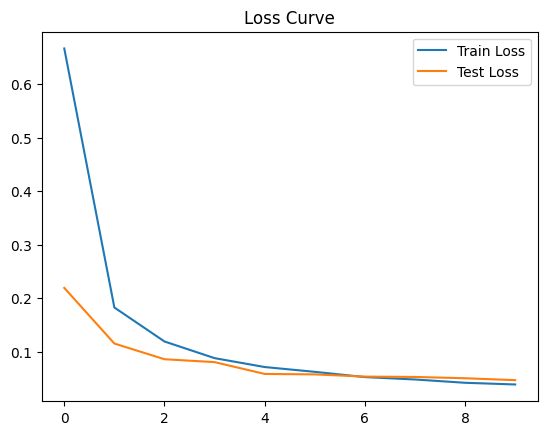

In [14]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses,  label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

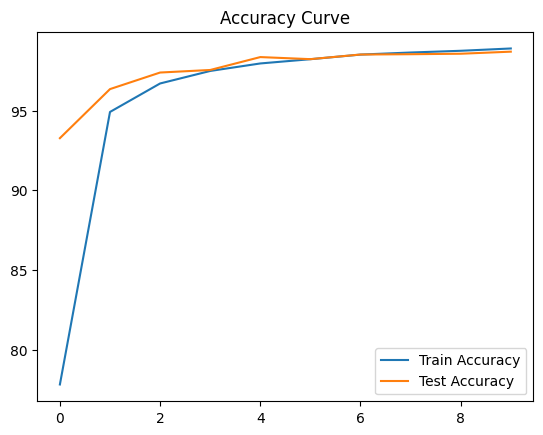

In [10]:
plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies,  label="Test Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

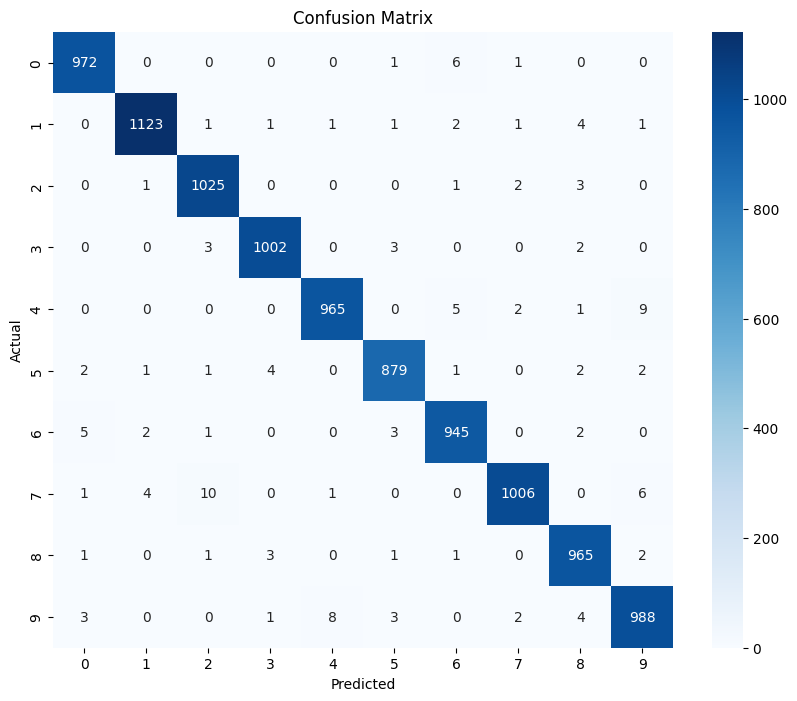

In [11]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs   = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

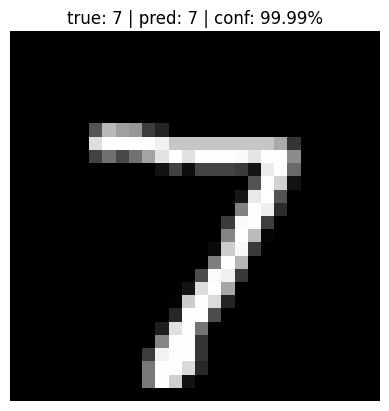

In [12]:
images, labels = next(iter(test_loader))

idx = 0
single_image = images[idx].unsqueeze(0)
true_label = labels[idx].item()

with torch.no_grad():
    output = model(single_image)
    
    probabilities = torch.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_label].item()

plt.imshow(images[idx].squeeze(), cmap='gray')
plt.title(f"true: {true_label} | pred: {predicted_label} | conf: {confidence:.2%}")
plt.axis('off')
plt.show()